In [50]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import cv2


In [51]:
img = cv2.imread("images/01_HSRM.jpg")

In [52]:
type(img), img.dtype, img.shape

(numpy.ndarray, dtype('uint8'), (785, 1200, 3))

In [53]:
img[123,123]

array([208, 192, 185], dtype=uint8)

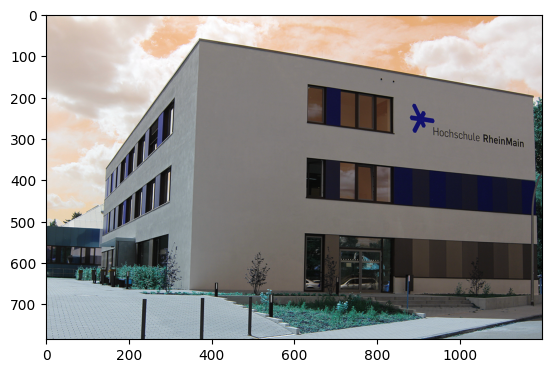

In [54]:
plt.imshow(img)
plt.show()

# Kapitel zu salt and pepper noise

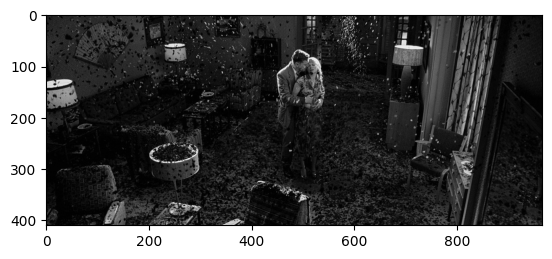

In [55]:
img = cv2.imread('images/shutter_island_colors.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap='grey')


Roberts Prewitt Sobel Edge Operations

In [56]:
def to_u8(z):
    z = z - z.min()
    z = z / z.max() * 255
    return z.astype(np.uint8)

In [57]:
# Roberts
HR1 = np.array([[ 0, 1], [-1, 0]], dtype=np.float32)
HR2 = np.array([[-1, 0], [ 0, 1]], dtype=np.float32)
# Prewitt
HPx = np.array([[1], [1], [1]]) * np.array([-1, 0, 1])
HPy = HPx.T
# Sobel
HSx = np.array([[1], [2], [1]]) * np.array([-1, 0, 1])
HSy = HSx.T

In [58]:
IR1, IR2, IPx, IPy, ISx, ISy = [
cv2.filter2D(img, cv2.CV_32F, k)/np.sum(np.abs(k))
for k in [HR1, HR2, HPx, HPy, HSx, HSy]]

mag_roberts = np.sqrt(IR1**2 + IR2**2)
mag_prewitt = np.sqrt(IPx**2 + IPy**2)
mag_sobel = np.sqrt(ISx**2 + ISy**2)

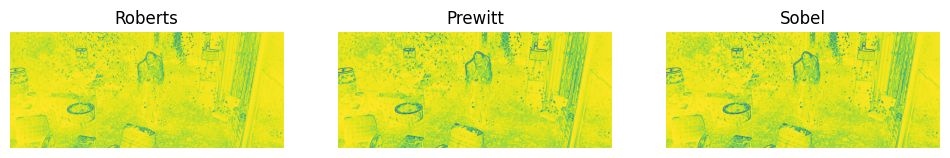

In [59]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1);
plt.title('Roberts'); plt.imshow(255-to_u8(mag_roberts)); plt.axis("off")
plt.subplot(1, 3, 2);
plt.title('Prewitt'); plt.imshow(255-to_u8(mag_prewitt)); plt.axis("off")
plt.subplot(1, 3, 3);
plt.title('Sobel'); plt.imshow(255-to_u8(mag_sobel)); plt.axis("off")
plt.show()

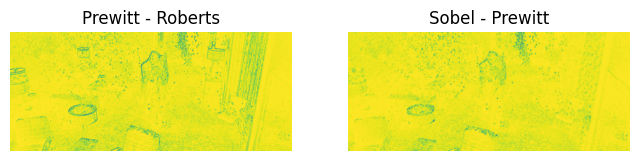

In [60]:
dRP = np.abs(mag_prewitt - mag_roberts)
dPS = np.abs(mag_sobel - mag_prewitt)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('Prewitt - Roberts'); plt.imshow(255-to_u8(dRP)); plt.axis("off")
plt.subplot(1, 2, 2)
plt.title('Sobel - Prewitt'); plt.imshow(255-to_u8(dPS)); plt.axis("off")
plt.show()

In [ ]:
img = cv2.imread('images/test/Bart_Simpson.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ... Edge Detection usw.m

In [62]:
# img = cv2.imread('images/test/Trump_Executive_Order.avif', cv2.IMREAD_GRAYSCALE)


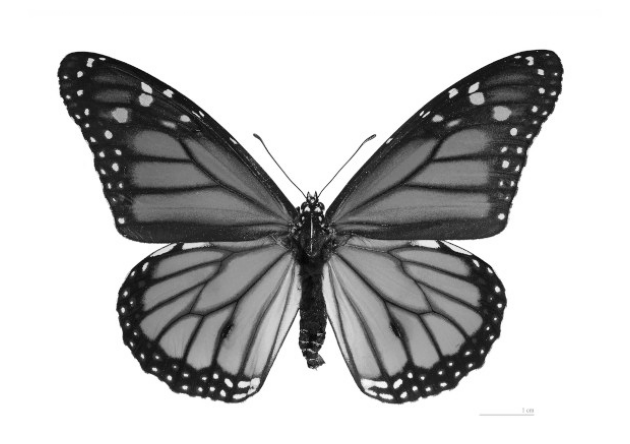

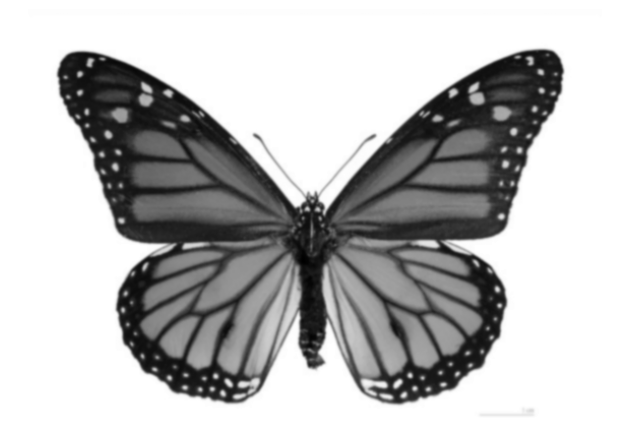

In [66]:
img = cv2.imread('images/test/Butterfly.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
sigma = 1
img_blur = cv2.GaussianBlur(img, (0,0), sigma)
plt.imshow(to_u8(img_blur), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

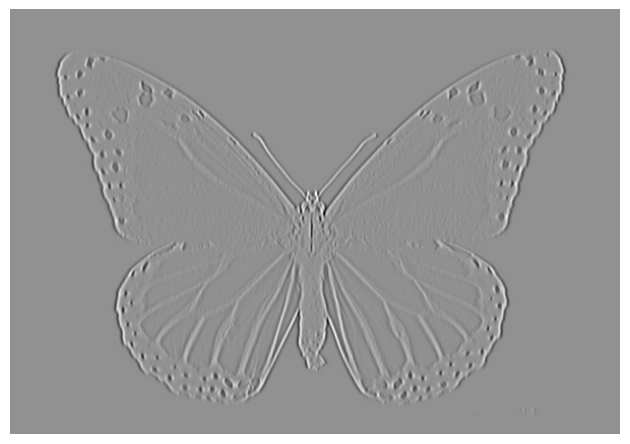

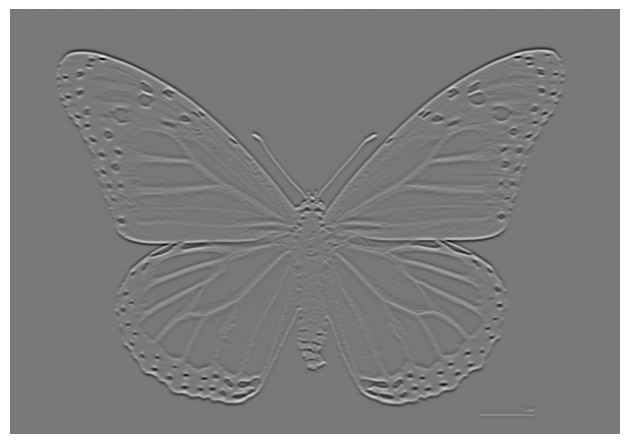

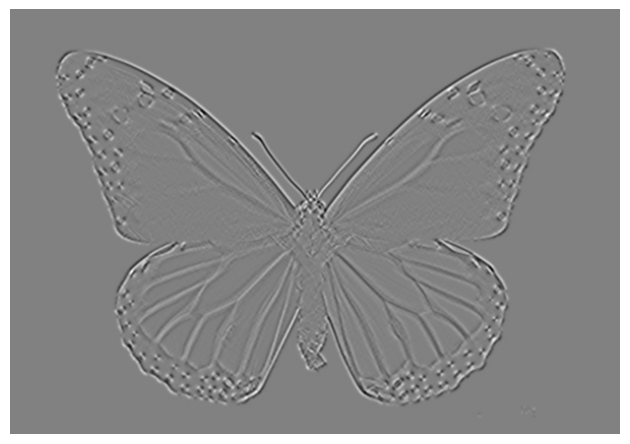

In [68]:
Ixx = cv2.Sobel(img_blur, cv2.CV_32F, 2, 0, ksize=3)
Iyy = cv2.Sobel(img_blur, cv2.CV_32F, 0, 2, ksize=3)
Ixy = cv2.Sobel(img_blur, cv2.CV_32F, 1, 1, ksize=3)

plt.imshow(to_u8(Ixx), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(to_u8(Iyy), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(to_u8(Ixy), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

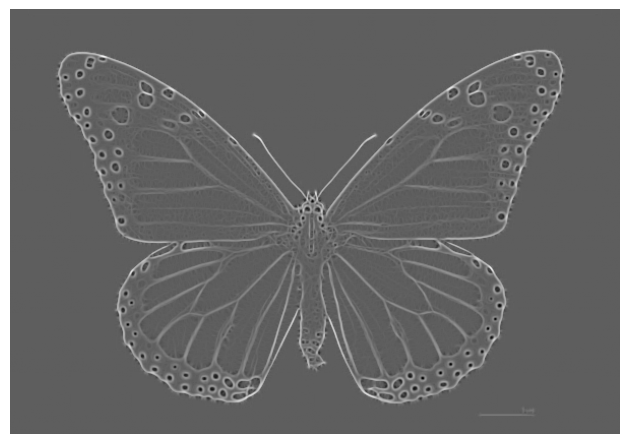

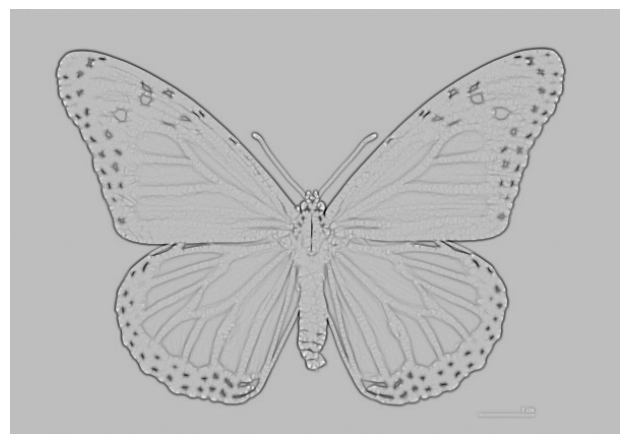

In [70]:
tmp = np.sqrt((Ixx - Iyy)**2 + 4*Ixy**2)
lambda1 = 0.5 * (Ixx + Iyy + tmp)
lambda2 = 0.5 * (Ixx + Iyy - tmp)
plt.imshow(to_u8(lambda1), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(to_u8(lambda2), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

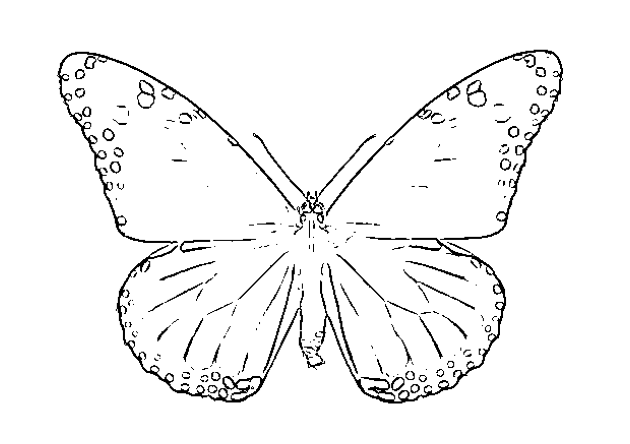

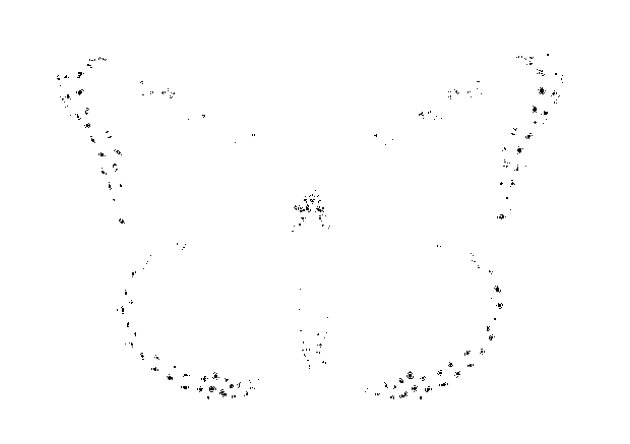

In [73]:
abs1 = np.abs(lambda1) # the response
abs2 = np.abs(lambda2) # distinguish between lines and blobs
# thresholds
thr1 = 0.2 * np.max(abs1)
thr2 = 0.2 * np.max(abs2)
lines = (abs1 > thr1) & (abs2 < thr1)
blobs = (abs1 > thr1) & (abs2 > thr2)
plt.imshow(255-to_u8(lines.astype(int)), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(255-to_u8(blobs.astype(int)), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()